In [6]:
#IMPORTACION DE LIBERIAS

# Manejo de datos
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

In [7]:
load_dotenv()

USER = os.getenv('POSTGRES_USER')
PASSWORD = os.getenv('POSTGRES_PASSWORD')
HOST = os.getenv('POSTGRES_HOST')
PORT = os.getenv('POSTGRES_PORT') 
DB = os.getenv('POSTGRES_DB')

engine = create_engine(f'postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

print("Conexión a la base de datos establecida")

Conexión a la base de datos establecida


In [ ]:
query = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    i.price,
    i.freight_value,
    p.product_category_name
FROM olist_orders_dataset o
INNER JOIN olist_order_items_dataset i 
    ON o.order_id = i.order_id
INNER JOIN olist_products_dataset p 
    ON i.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND p.product_category_name IS NOT NULL
  AND o.order_purchase_timestamp >= '2017-01-01'  ;
"""

In [9]:
# Extraemos el dataset maestro utilizando el motor de conexión que ya tenías (engine)
df_master = pd.read_sql(query, engine)

# Convertimos inmediatamente la fecha de texto a formato Datetime de Pandas
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])

print("Dataset maestro primera version")
print(df_master.info())
print()
print(df_master.head())


Dataset maestro primera version
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108345 entries, 0 to 108344
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  108345 non-null  object        
 1   order_purchase_timestamp  108345 non-null  datetime64[ns]
 2   price                     108345 non-null  float64       
 3   freight_value             108345 non-null  float64       
 4   product_category_name     108345 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 4.1+ MB
None

                           order_id order_purchase_timestamp  price  \
0  00018f77f2f0320c557190d7a144bdd3      2017-04-26 10:53:06  239.9   
1  000229ec398224ef6ca0657da4fc703e      2018-01-14 14:33:31  199.0   
2  00042b26cf59d7ce69dfabb4e55b4fd9      2017-02-04 13:57:51  199.9   
3  00048cc3ae777c65dbb7d2a0634bc1ea      2017-05-15 21:4

In [ ]:
# 1. Preparación temporal (Agrupar por Año y Mes) de '2017-10-02 10:56:33' a '2017-10'
df_master['year_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')
# 'M' -> Toma la fecha y la recorta al periodo: mes +año

# Agrupamos contando cuántos artículos se vendieron en cada mes
ventas_mensuales = df_master.groupby('year_month').size().reset_index(name='total_articulos_vendidos')
#    year_month  total_articulos_vendidos
# 0     2023-01                       500

# Convertimos el periodo a texto para que se grafique
ventas_mensuales['year_month'] = ventas_mensuales['year_month'].astype(str)


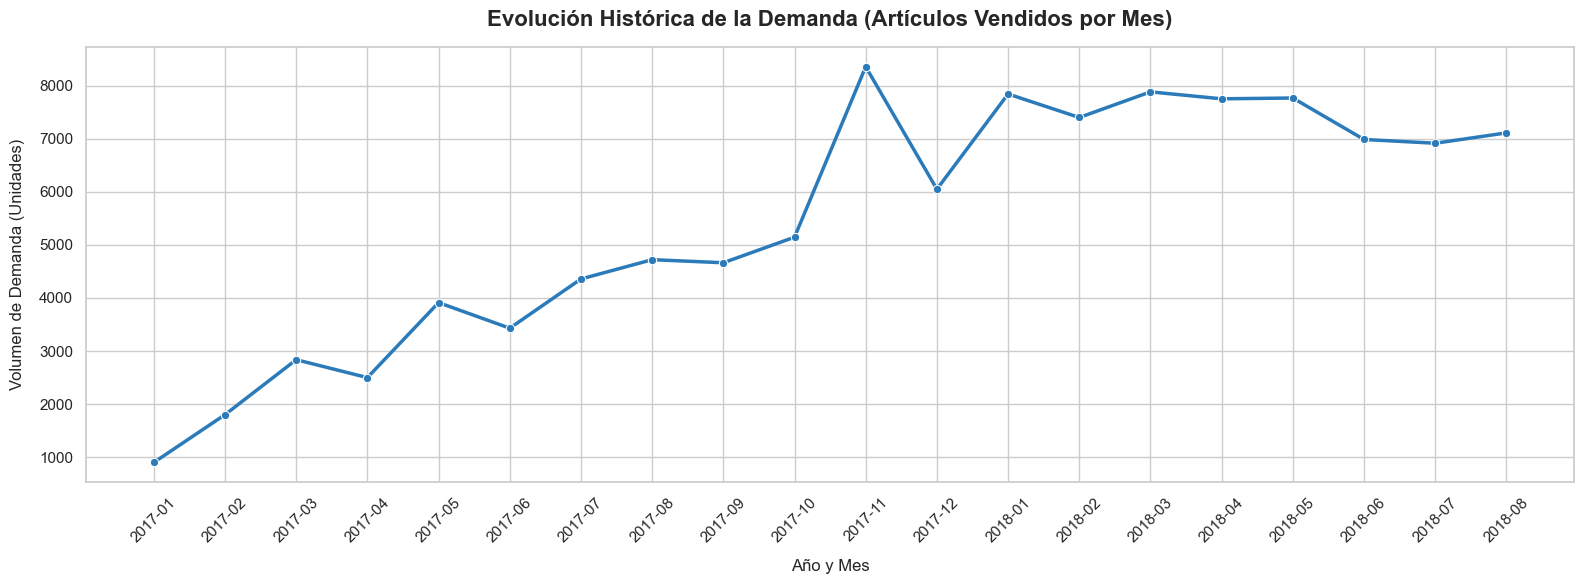

In [ ]:
# Como se comporta la variable del tiempo.
sns.set_theme(style="whitegrid") # configurar el diseño estético global para todas las gráficas
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=ventas_mensuales, 
    x='year_month', 
    y='total_articulos_vendidos', 
    marker='o',                
    color="#ff0000",           
    linewidth=3
)
plt.title('Evolución Histórica de la Demanda (Artículos Vendidos por Mes)', fontsize=20, fontweight='bold', pad=15)
plt.xlabel('Año y Mes', fontsize=12, labelpad=10)
plt.ylabel('Volumen de Demanda (Unidades)', fontsize=12, labelpad=10)
plt.xticks(rotation=45) # Giramos las etiquetas del eje X
plt.tight_layout()
plt.show()

In [ ]:
# Preparación Mínima (El "Mini" Feature Engineering)

# Extraccion de fechas
df_master['purchase_year'] = df_master['order_purchase_timestamp'].dt.year
df_master['purchase_month'] = df_master['order_purchase_timestamp'].dt.month
df_master['purchase_day'] = df_master['order_purchase_timestamp'].dt.day
df_master['purchase_day_number'] = df_master['order_purchase_timestamp'].dt.weekday

# Devuelven TRUE o FALSE, estos se vuelven a int
# is_black_friday (Noviembre)
df_master['is_black_friday'] = (df_master['purchase_month'] == 11).astype(int)
# is_weekend
df_master['is_weekend'] = (df_master['purchase_day_number'] >= 5 ).astype(int)
# is_free_shipping
df_master['is_free_shipping'] = (df_master['freight_value'] == 0).astype(int)

print(df_master.info())
print(df_master.head())

- Crear el target mediante una agrupación. Este no existe actualmente como una columna solitaria en tu base de datos esperando a ser elegida.

- Cada fila representa un solo artículo vendido. Usando tu tabla actual tal como está, el algoritmo se confundirá y siempre predecirá 1.

- En Machine Learning, intentar predecir producto por producto en un e-commerce se topa con el peor enemigo de los algoritmos: La Dispersión de los Datos (Data Sparsity)

In [ ]:
# Crea una combinacion para cada parametro del groupby
# Si en alguna fecha la categoria tuvo 0 ventas, Pandas no creará la fila con un cero; simplemente se saltará esa categoría en ese mes.

df_modelo = df_master.groupby(
    ['purchase_year', 'purchase_month', 'product_category_name']
    ).agg(  # Todo por mes - año - categoria
    target_demanda=('order_id', 'count'), # Target, cuantas ventas por categoria
    precio_promedio=('price', 'mean'), # Promedio del precio por categoria
    es_black_friday=('is_black_friday', 'max'), # Variable binaria
    es_fin_de_semana=('is_weekend', 'mean'),
    es_envio_gratis=('is_free_shipping', 'mean') 
).reset_index()

# Ordenamos por año y mes para que quede como una línea de tiempo real
df_modelo = df_modelo.sort_values(['purchase_year', 'purchase_month'])

print(df_modelo.sample(5))
print(df_modelo.info())

,purchase_year,purchase_month,product_category_name,target_demanda,precio_promedio,es_black_friday,es_fin_de_semana,es_envio_gratis
78,2017,2,moveis_cozinha_area_de_servico_jantar_e_jardim,2,69.950000,0,0.500000,0.0
506,2017,9,telefonia_fixa,13,1053.300769,0,0.076923,0.0
359,2017,7,instrumentos_musicais,30,242.753000,0,0.100000,0.0
422,2017,8,livros_interesse_geral,27,84.259259,0,0.148148,0.0
1120,2018,7,eletroportateis,42,194.317857,0,0.166667,0.0


En esta parte de la preparacion de los datos, no podemos hacer un split tradicionarl, ya que las fechas estarian mezcladas y haria del entrenamiento algo catastrofico.

Haremos una separacion de fechas con forma 75/25 basandonos en el tiempo (20 meses): dejamos 15 meses para entrenar (Train) y 5 meses para examinar (Test). Eso equivale a un 75/25.

In [ ]:
# 1. Definimos la máscara temporal 
# A partir de Abril 2018 será Test
mask_test = (df_modelo['purchase_year'] == 2018) & (df_modelo['purchase_month'] >= 4)

# 2. Dividimos el DataFrame cronológicamente
df_train = df_modelo[~mask_test]
df_test = df_modelo[mask_test]  

print(f"Filas para Entrenamiento: {len(df_train)}")
print(f"Filas para Prueba: {len(df_test)}")

# 3. Separamos X y Y (Target) para ambos conjuntos
# y
y_train = df_train['target_demanda']
y_test = df_test['target_demanda']

# Los algoritmos basados en árboles de decisión (como tu Random Forest) son geniales interpolando (conectando puntos conocidos), pero son pésimos extrapolando (adivinando el futuro)
# El modelo interpreta ese 1 a 12 como una magnitud lineal de tamaño o valor. Pensará que el mes 12 (Diciembre) "vale el doble" que el mes 6 (Junio).

columnas_a_tirar = ['target_demanda', 'purchase_year', 'purchase_month']
X_train = df_train.drop(columns=columnas_a_tirar)
X_test = df_test.drop(columns=columnas_a_tirar)

Meses de Entrenamiento (Filas): 894
Meses de Prueba (Filas): 327


In [ ]:
#aqui


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

# 1. El Director de Tráfico (Preprocesador)
preprocesador = ColumnTransformer(
    transformers=[
        # Transformamos SOLO la categoría. 
        # 'handle_unknown=ignore' es un salvavidas: si en el Test aparece una 
        # categoría nueva que no estaba en el Train, no rompe el código, la vuelve ceros.
        ('categorico', OneHotEncoder(handle_unknown='ignore'), ['product_category_name'])
    ],
    remainder='passthrough' # Deja pasar intactas el resto de columnas numéricas (Tus features)
)

# 2. La Línea de Ensamblaje (Pipeline)
pipeline_rf = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    # Instanciamos el modelo con una semilla (random_state) para que tus resultados 
    # sean exactamente reproducibles cada vez que corras la celda
    ('modelo', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 3. ¡El momento de la verdad! Entrenamos el Pipeline completo
# Nota: Le pasamos X_train (texto y números) y el Pipeline hace la conversión internamente
pipeline_rf.fit(X_train, y_train)

print("¡Modelo Baseline entrenado exitosamente!")

¡Modelo Baseline entrenado exitosamente!


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Hacemos que el Pipeline prediga sobre los datos de examen (El futuro)
# Nota que no usamos .fit(), solo .predict(), porque ya aprendió en el Train.
predicciones = pipeline_rf.predict(X_test)

# 2. Calculamos la Trinidad de las Métricas
mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

# 3. Imprimimos el boletín de calificaciones
print("==================================================")
print("📊 RESULTADOS DEL MODELO BASELINE (DATOS DE PRUEBA)")
print("==================================================")
print(f"MAE  (Error Absoluto Medio) : {mae:.2f} unidades")
print(f"RMSE (Error Cuadrático)     : {rmse:.2f} unidades")
print(f"R²   (Poder Explicativo)    : {r2:.4f} ({(r2*100):.1f}%)")
print("==================================================")

📊 RESULTADOS DEL MODELO BASELINE (DATOS DE PRUEBA)
MAE  (Error Absoluto Medio) : 40.41 unidades
RMSE (Error Cuadrático)     : 85.81 unidades
R²   (Poder Explicativo)    : 0.7706 (77.1%)


In [18]:
from sklearn.linear_model import LinearRegression

# 1. Reciclamos el director de tráfico (preprocesador) que ya tenías
# y lo conectamos al nuevo algoritmo
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LinearRegression())
])

# 2. Entrenamos la Regresión Lineal con los mismos datos del pasado
pipeline_lr.fit(X_train, y_train)

# 3. Le pedimos que prediga el futuro
predicciones_lr = pipeline_lr.predict(X_test)

# 4. Calculamos sus métricas
mae_lr = mean_absolute_error(y_test, predicciones_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, predicciones_lr))
r2_lr = r2_score(y_test, predicciones_lr)

# 5. Comparamos resultados
print("==================================================")
print("📈 RESULTADOS: REGRESIÓN LINEAL BASELINE")
print("==================================================")
print(f"MAE  (Error Absoluto Medio) : {mae_lr:.2f} unidades")
print(f"RMSE (Error Cuadrático)     : {rmse_lr:.2f} unidades")
print(f"R²   (Poder Explicativo)    : {r2_lr:.4f} ({(r2_lr*100):.1f}%)")
print("==================================================")

📈 RESULTADOS: REGRESIÓN LINEAL BASELINE
MAE  (Error Absoluto Medio) : 46.80 unidades
RMSE (Error Cuadrático)     : 92.79 unidades
R²   (Poder Explicativo)    : 0.7317 (73.2%)


In [ ]:
01_extraccion_y_eda.ipynb (El tuyo actual): Llega hasta donde estás ahora. Carga el SQL, limpia los nulos, hace las gráficas, crea las primeras variables y establece el Baseline para saber si el proyecto es viable. Al final de este notebook, exportas tu df_modelo a un archivo .csv o .parquet limpio.

02_modelado_avanzado.ipynb: Aquí crearás un archivo nuevo. Importas ese .csv limpio (para no tener que correr todo el SQL de nuevo) y te dedicas exclusivamente a la experimentación pesada: crear variables de tiempo más complejas, ajustar hiperparámetros y entrenar modelos como XGBoost.